# Dự Đoán Sản Lượng Điện Mặt Trời — Pipeline Hoàn Chỉnh
**Dataset:** DKASC Alice Springs — Site 10, SunPower 5.8 kW, mono-Si, Fixed (2019–2022)
**Pipeline:** Thu thập dữ liệu → Tiền xử lý → EDA → Xây dựng mô hình → So sánh 6 models
**Models:** Persistence · Linear Regression · XGBoost · LSTM · CNN-LSTM · GRU

## 0. Cấu Hình & Thư Viện

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pvlib
from pvlib import solarposition
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, MaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'figure.dpi'       : 120,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
    'axes.labelsize'   : 11,
    'axes.labelcolor'  : '#333333',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : '#e0e0e0',
    'grid.linewidth'   : 0.8,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'legend.framealpha': 0.9,
    'font.family'      : 'DejaVu Sans',
})
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {
    'ghi'  : '#f4a261',
    'dhi'  : '#e9c46a',
    'dni'  : '#e76f51',
    'power': '#2a9d8f',
    'temp' : '#e63946',
    'humid': '#457b9d',
    'sza'  : '#6a4c93',
}

LAT, LON, ALTITUDE, TZ = -23.762, 133.875, 546, 'Australia/Darwin'

LOOKBACK      = 24
HORIZONS      = [1, 4, 24]
HORIZON_NAMES = ['t+1', 't+4', 't+24']
FEATURE_COLS  = ['GHI', 'DHI', 'DNI', 'air_temperature', 'relative_humidity', 'solar_zenith_angle']
TARGET_COL    = 'Active_Power'

RAW_PATH  = '../data/raw/dkasc/71-Site_DKA-M2_C-Phase.csv'
SAVE_PATH = '../data/processed/dkasc_hourly_clean.csv'
MODEL_DIR = '../models'
os.makedirs('../data/processed', exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.21.0


## 1. Thu Thập Dữ Liệu

**DKASC Alice Springs** phải tải thủ công qua website:

1. Truy cập: https://dkasolarcentre.com.au/download?location=alice-springs
2. Chọn site: **Site 10 — SunPower 5.8 kW, mono-Si, Fixed, 2009**
3. Chọn khoảng thời gian: 2019–2022
4. Lưu file CSV vào: `data/raw/dkasc/`

File sử dụng: `71-Site_DKA-M2_C-Phase.csv` (dataset gộp toàn bộ năm)



In [2]:
if os.path.exists(RAW_PATH):
    size_mb = os.path.getsize(RAW_PATH) / 1024 / 1024
    print(f'[ok]      {RAW_PATH}')
    print(f'          Kích thước: {size_mb:.1f} MB')
else:
    print(f'[missing] {RAW_PATH}')
    print('Vui lòng tải file theo hướng dẫn bên trên.')

[ok]      ../data/raw/dkasc/71-Site_DKA-M2_C-Phase.csv
          Kích thước: 279.1 MB


## 2. Tải & Kiểm Tra Dữ Liệu Thô

In [3]:
df_raw = pd.read_csv(RAW_PATH, on_bad_lines='skip', parse_dates=['timestamp'])

print(f'Tổng số hàng: {len(df_raw):,}')
print(f'Thời gian   : {df_raw["timestamp"].min()} → {df_raw["timestamp"].max()}')
print(f'Số cột      : {len(df_raw.columns)}')

Tổng số hàng: 1,771,458
Thời gian   : 2008-09-12 05:55:00 → 2025-09-04 12:05:00
Số cột      : 14


In [4]:
df_raw.head()

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Performance_Ratio,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
0,2008-09-12 05:55:00,0.0,0.0,0.0,NaN,NaN,25.734350,18.551216,5.227983,2.215820,103.423134,0.0,NaN,NaN
1,2008-09-12 06:00:00,0.0,0.0,0.0,NaN,NaN,25.402353,19.242727,5.408280,2.435364,125.776703,0.0,NaN,NaN
2,2008-09-12 06:05:00,0.0,0.0,0.0,NaN,NaN,25.141418,19.368038,4.931451,1.885518,163.055115,0.0,NaN,NaN
3,2008-09-12 06:10:00,0.0,0.0,0.0,NaN,NaN,25.015263,19.301992,4.298166,1.327833,137.553268,0.0,NaN,NaN
4,2008-09-12 06:15:00,0.0,0.0,0.0,NaN,NaN,24.935015,19.123230,4.499399,1.520790,128.099182,0.0,NaN,NaN


## 3. Tiền Xử Lý

### 3.1 Lọc Giai Đoạn 2019–2022

In [5]:
mask = (df_raw['timestamp'].dt.year >= 2019) & (df_raw['timestamp'].dt.year <= 2022)
df = df_raw[mask].copy()
df = df.set_index('timestamp').sort_index()

df = df.rename(columns={
    'Global_Horizontal_Radiation' : 'GHI',
    'Diffuse_Horizontal_Radiation': 'DHI',
    'Weather_Temperature_Celsius' : 'air_temperature',
    'Weather_Relative_Humidity'   : 'relative_humidity',
})

cols_keep = ['GHI', 'DHI', 'air_temperature', 'relative_humidity', 'Active_Power']

print(f'Số hàng sau lọc 2019–2022: {len(df):,}')
print(f'Thời gian                : {df.index.min()} → {df.index.max()}')
print()
print('Null (cột sử dụng):')
print(df[cols_keep].isnull().sum())

Số hàng sau lọc 2019–2022: 411,728
Thời gian                : 2019-01-01 00:00:00 → 2022-12-31 23:55:00

Null (cột sử dụng):
GHI                  29
DHI                  29
air_temperature      28
relative_humidity    28
Active_Power         22
dtype: int64


### 3.2 Resample về Hourly

Dữ liệu gốc ở tần suất **5 phút**. Resample về **hourly** bằng mean aggregation — lookback 24 bước = 24 giờ.

In [6]:
df_h = df[cols_keep].resample('1h').mean()

print(f'Số hàng sau resample: {len(df_h):,}')
print(f'Thời gian           : {df_h.index.min()} → {df_h.index.max()}')
print()
print('Null sau resample:')
print(df_h.isnull().sum())

Số hàng sau resample: 35,064
Thời gian           : 2019-01-01 00:00:00 → 2022-12-31 23:00:00

Null sau resample:
GHI                  738
DHI                  738
air_temperature      738
relative_humidity    738
Active_Power         738
dtype: int64


### 3.3 Tính Solar Zenith Angle (pvlib)

Dùng `apparent_zenith` — bao gồm hiệu chỉnh khúc xạ khí quyển, chính xác hơn `zenith` thuần thiên văn.

In [7]:
times_local = df_h.index.tz_localize(TZ)

solpos = solarposition.get_solarposition(
    time      = times_local,
    latitude  = LAT,
    longitude = LON,
    altitude  = ALTITUDE,
    method    = 'nrel_numpy'
)

df_h['solar_zenith_angle'] = solpos['apparent_zenith'].values
print(f'SZA — min: {df_h["solar_zenith_angle"].min():.2f}°  max: {df_h["solar_zenith_angle"].max():.2f}°')

SZA — min: 4.51°  max: 175.13°


### 3.4 Tính DNI

$$\text{DNI} = \frac{\text{GHI} - \text{DHI}}{\cos(\text{SZA})}$$

Clip $\cos(\text{SZA})$ tại 0.087 (tương đương SZA = 85°) để tránh chia cho số gần 0.

In [8]:
sza_rad = np.radians(df_h['solar_zenith_angle'])
cos_sza = np.cos(sza_rad).clip(lower=0.087)

df_h['DNI'] = ((df_h['GHI'] - df_h['DHI']) / cos_sza).clip(lower=0)
df_h.loc[df_h['GHI'] == 0, 'DNI'] = 0.0

print(f'DNI — min: {df_h["DNI"].min():.1f}  max: {df_h["DNI"].max():.1f}  mean: {df_h["DNI"].mean():.1f} W/m²')

DNI — min: 0.0  max: 1598.6  mean: 360.1 W/m²


### 3.5 Lọc Ban Ngày & Xử Lý Outlier

Ngưỡng kép: `GHI > 10 W/m²` AND `SZA < 85°` (filter `GHI > 0` quá lỏng — để lọt sensor noise ban đêm).
Loại nhiệt độ bất hợp lý: min = −39.99°C là lỗi sensor, Alice Springs không xuống dưới 0°C trong giờ có bức xạ.

In [9]:
n_total = len(df_h)

daytime_mask = (df_h['GHI'] > 10) & (df_h['solar_zenith_angle'] < 85)
df_day = df_h[daytime_mask].copy()

print(f'Số hàng gốc (hourly)       : {n_total:,}')
print(f'Sau filter GHI>10 & SZA<85 : {len(df_day):,}')
print(f'Tỷ lệ giữ lại              : {len(df_day)/n_total*100:.1f}%')

df_day = df_day[FEATURE_COLS + [TARGET_COL]]

n_before = len(df_day)
df_day   = df_day[df_day['air_temperature'] > 0]
print(f'Hàng drop do nhiệt độ      : {n_before - len(df_day)}')

n_before = len(df_day)
df_day   = df_day.dropna()
print(f'Hàng drop do null          : {n_before - len(df_day)}')
print(f'Số hàng cuối cùng          : {len(df_day):,}')
print()
df_day.isnull().sum()

Số hàng gốc (hourly)       : 35,064
Sau filter GHI>10 & SZA<85 : 15,836
Tỷ lệ giữ lại              : 45.2%
Hàng drop do nhiệt độ      : 106
Hàng drop do null          : 0
Số hàng cuối cùng          : 15,730



GHI                   0
DHI                   0
DNI                   0
air_temperature       0
relative_humidity     0
solar_zenith_angle    0
Active_Power          0
dtype: int64

### 3.6 Kiểm Tra Tổng Kết

In [10]:
n       = len(df_day)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

print(f'Số hàng      : {n:,}')
print(f'Số cột       : {len(df_day.columns)}')
print(f'Thời gian    : {df_day.index.min()} → {df_day.index.max()}')
print(f'Null còn lại : {df_day.isnull().sum().sum()}')
print()
print(f'Train (70%): {n_train:,}  →  {df_day.index[0]}  –  {df_day.index[n_train-1]}')
print(f'Val   (15%): {n_val:,}   →  {df_day.index[n_train]}  –  {df_day.index[n_train+n_val-1]}')
print(f'Test  (15%): {n_test:,}  →  {df_day.index[n_train+n_val]}  –  {df_day.index[-1]}')

Số hàng      : 15,730
Số cột       : 7
Thời gian    : 2019-01-01 07:00:00 → 2022-12-31 18:00:00
Null còn lại : 0

Train (70%): 11,011  →  2019-01-01 07:00:00  –  2021-10-29 09:00:00
Val   (15%): 2,359   →  2021-10-29 10:00:00  –  2022-06-01 09:00:00
Test  (15%): 2,360  →  2022-06-01 10:00:00  –  2022-12-31 18:00:00


### 3.7 Lưu File Đã Xử Lý

In [11]:
df_day.to_csv(SAVE_PATH)
print(f'Đã lưu : {SAVE_PATH}')
print(f'Size   : {os.path.getsize(SAVE_PATH)/1024:.1f} KB')

Đã lưu : ../data/processed/dkasc_hourly_clean.csv
Size   : 2288.3 KB


## 4. Phân Tích Khám Phá Dữ Liệu (EDA)

### 4.1 Thống Kê Mô Tả

In [12]:
desc = df_day.describe().T
desc.columns = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
desc = desc.round(2)
units = {
    'GHI': 'W/m²', 'DHI': 'W/m²', 'DNI': 'W/m²',
    'air_temperature': '°C', 'relative_humidity': '%',
    'solar_zenith_angle': '°', 'Active_Power': 'kW',
}
desc.insert(0, 'unit', pd.Series(units))
desc

,unit,count,mean,std,min,25%,50%,75%,max
GHI,W/m²,15730.0,587.24,331.89,10.01,305.88,612.11,851.55,1253.59
DHI,W/m²,15730.0,115.39,100.73,8.36,56.87,79.69,129.16,682.85
DNI,W/m²,15730.0,743.35,408.05,0.29,392.75,884.70,1075.74,1509.94
air_temperature,°C,15730.0,26.34,8.06,2.52,20.35,26.57,32.69,45.23
relative_humidity,%,15730.0,25.52,17.54,3.01,13.01,20.89,31.83,102.26
solar_zenith_angle,°,15730.0,49.98,20.28,4.51,35.51,50.40,66.71,85.00
Active_Power,kW,15730.0,2.70,1.45,0.00,1.46,2.96,4.04,5.14


### 4.2 Phân Phối Các Features

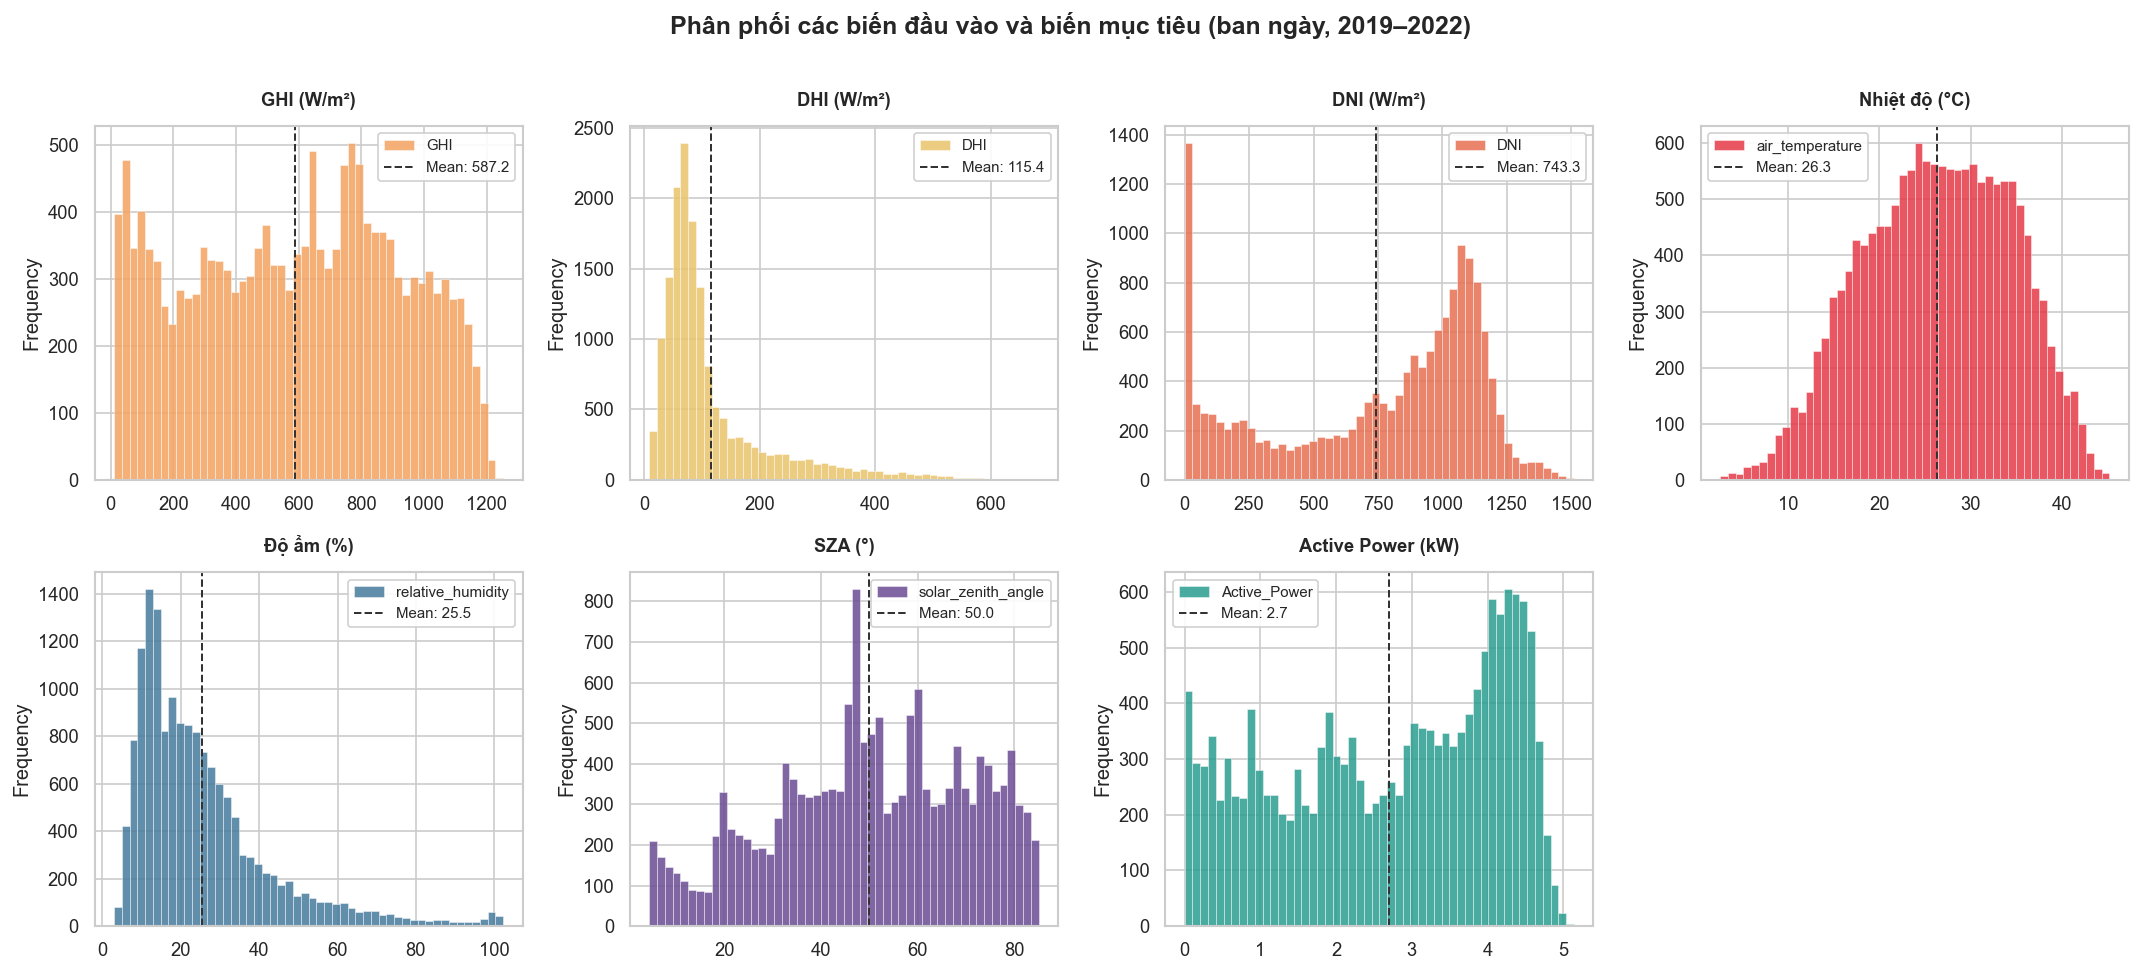

In [13]:
plot_cfg = [
    ('GHI',                'GHI (W/m²)',        COLORS['ghi']),
    ('DHI',                'DHI (W/m²)',        COLORS['dhi']),
    ('DNI',                'DNI (W/m²)',        COLORS['dni']),
    ('air_temperature',    'Nhiệt độ (°C)',     COLORS['temp']),
    ('relative_humidity',  'Độ ẩm (%)',         COLORS['humid']),
    ('solar_zenith_angle', 'SZA (°)',           COLORS['sza']),
    ('Active_Power',       'Active Power (kW)', COLORS['power']),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Phân phối các biến đầu vào và biến mục tiêu (ban ngày, 2019–2022)',
             fontsize=15, fontweight='bold', y=1.01)

for i, (col, label, color) in enumerate(plot_cfg):
    r, c = divmod(i, 4)
    ax = axes[r][c]
    df_day[col].plot.hist(bins=50, ax=ax, color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    mean_val = df_day[col].mean()
    ax.axvline(mean_val, color='#333', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=9)

axes[1][3].set_visible(False)
plt.tight_layout()
plt.savefig('../data/processed/fig_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét:**
- **GHI** (mean 587 W/m²): phân phối lệch phải điển hình — nhiều giờ có bức xạ thấp đến trung bình, đuôi dài về phía cao do các giờ trưa trời quang.
- **DHI** (mean 115 W/m²): lệch mạnh về phía thấp, xác nhận khí hậu khô hạn ít mây của Alice Springs.
- **DNI** (mean 743 W/m²): phân phối lưỡng đỉnh rõ — hai trạng thái: nhiều mây (DNI thấp ~0–200 W/m²) và trời quang (DNI cao ~800–1400 W/m²).
- **Nhiệt độ** (mean 26.3°C): phân phối gần chuẩn, range 5–45°C, hợp lý cho Alice Springs ban ngày.
- **Độ ẩm** (mean 25.5%): lệch phải, phần lớn giờ ban ngày có độ ẩm dưới 40%.
- **SZA** (mean 50.0°): phân phối tương đối đều từ 0–85°, xác nhận filter đúng.
- **Active Power** (mean 2.7 kW): có hai cụm — đầu/cuối ngày (0–1 kW) và giờ cao điểm (3–5 kW).

### 4.3 Sản Lượng Theo Tháng

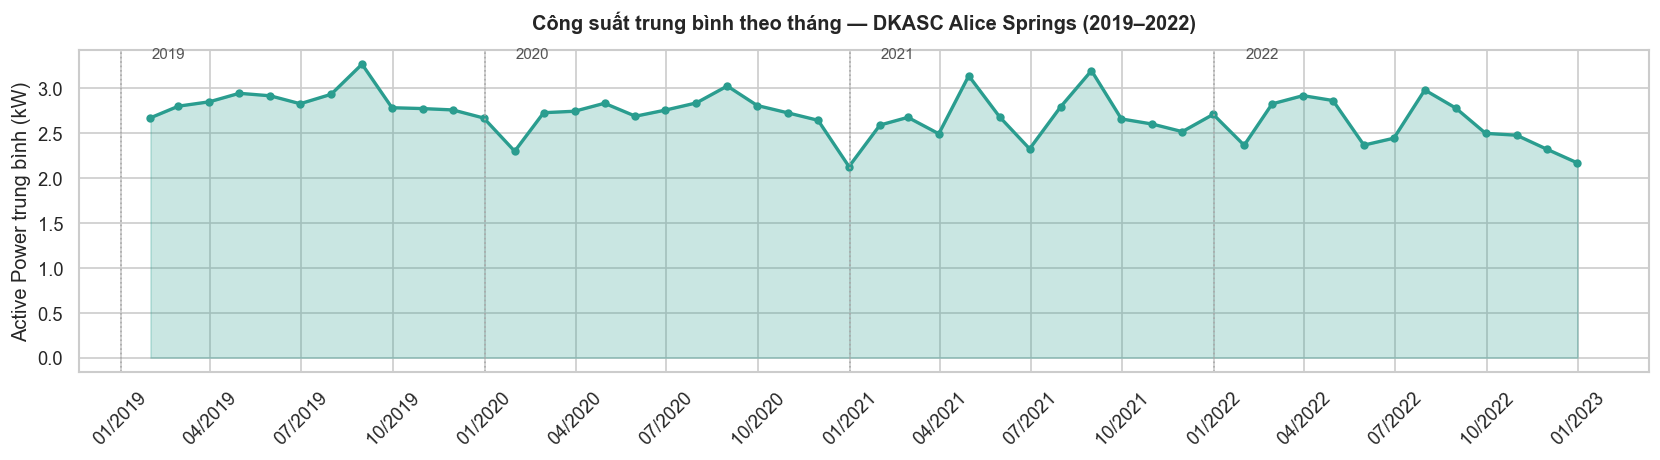

In [14]:
monthly = df_day['Active_Power'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly.index, monthly.values, alpha=0.25, color=COLORS['power'])
ax.plot(monthly.index, monthly.values, color=COLORS['power'], linewidth=2, marker='o', markersize=4)
ax.set_title('Công suất trung bình theo tháng — DKASC Alice Springs (2019–2022)', fontweight='bold')
ax.set_ylabel('Active Power trung bình (kW)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
for yr in [2019, 2020, 2021, 2022]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='#aaa', linestyle=':', linewidth=1)
    ax.text(pd.Timestamp(f'{yr}-02-01'), monthly.max() * 1.02, str(yr), fontsize=9, color='#555')
plt.tight_layout()
plt.savefig('../data/processed/fig_monthly_power.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét:**
- Công suất dao động 2.1–3.3 kW qua 4 năm, pattern tương đối bằng phẳng — Alice Springs có bức xạ ổn định quanh năm do gần chí tuyến.
- Xu hướng giảm nhẹ qua các năm phù hợp với panel degradation tự nhiên (~0.5%/năm với mono-Si).
- Đỉnh cao nhất tại T10/2019 (~3.3 kW): mùa xuân Úc — bức xạ cao, nhiệt độ chưa cực đoan.
- Dip tại T1/2021 (~2.1 kW): có thể do sự kiện thời tiết bất thường hoặc downtime thiết bị.

### 4.4 Bức Xạ Theo Tháng (GHI / DNI / DHI)

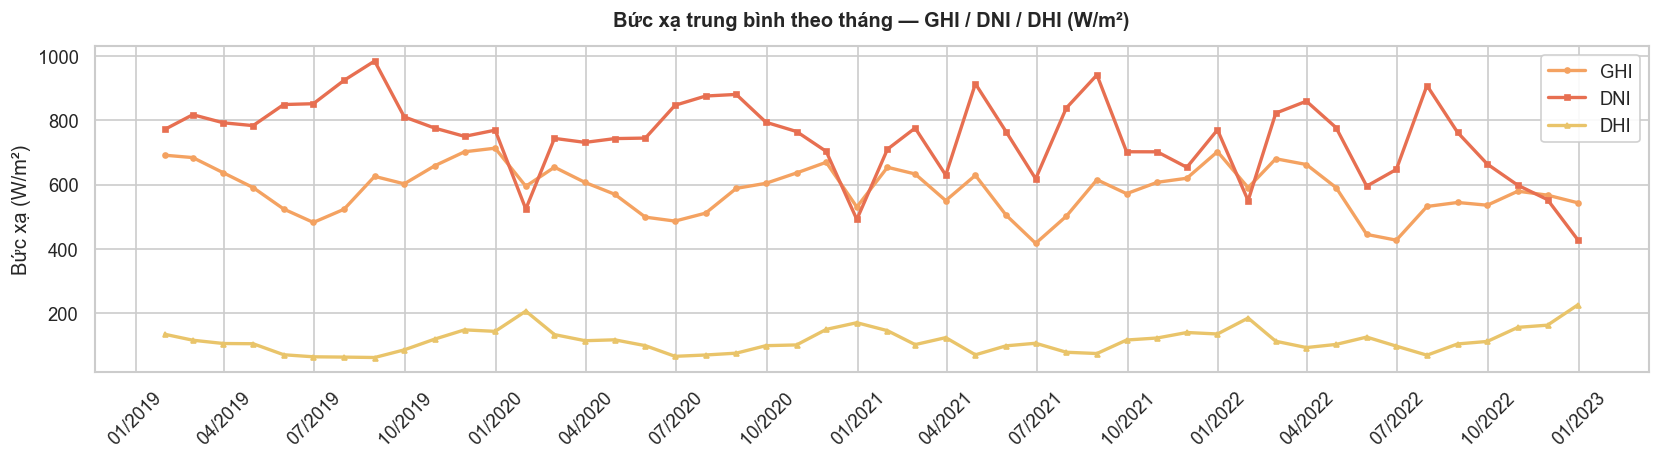

In [15]:
rad_monthly = df_day[['GHI', 'DNI', 'DHI']].resample('ME').mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rad_monthly.index, rad_monthly['GHI'], color=COLORS['ghi'], linewidth=2, label='GHI', marker='o', markersize=3)
ax.plot(rad_monthly.index, rad_monthly['DNI'], color=COLORS['dni'], linewidth=2, label='DNI', marker='s', markersize=3)
ax.plot(rad_monthly.index, rad_monthly['DHI'], color=COLORS['dhi'], linewidth=2, label='DHI', marker='^', markersize=3)
ax.set_title('Bức xạ trung bình theo tháng — GHI / DNI / DHI (W/m²)', fontweight='bold')
ax.set_ylabel('Bức xạ (W/m²)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/fig_monthly_radiation.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét:**
- DNI luôn cao hơn GHI — đúng về vật lý: GHI = DNI·cos(SZA) + DHI, khi SZA > 0° thì GHI < DNI.
- DNI đạt đỉnh vào T9–T10 — mùa xuân Úc, bầu trời quang đãng nhất trong năm.
- DHI ổn định thấp (~100–200 W/m²), tăng nhẹ cuối năm (mùa mưa → mây khuếch tán tăng).

### 4.5 Profile Theo Giờ & Mùa

Alice Springs (Nam bán cầu): mùa hè tháng 12–2, mùa đông tháng 6–8.

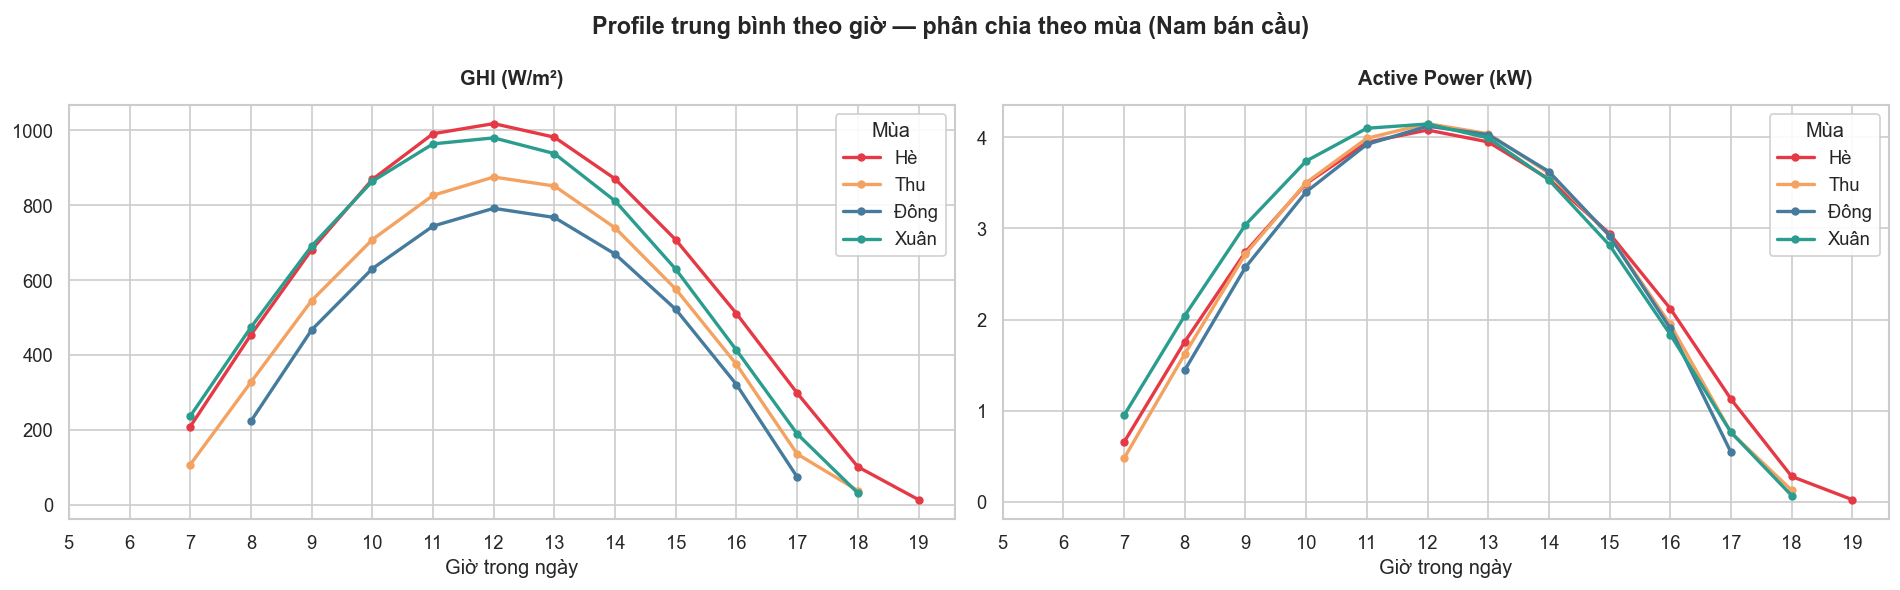

In [16]:
df_eda = df_day.copy()
df_eda['hour']   = df_eda.index.hour
df_eda['month']  = df_eda.index.month
df_eda['season'] = df_eda['month'].map({
    12: 'Hè', 1: 'Hè',  2: 'Hè',
    3: 'Thu', 4: 'Thu', 5: 'Thu',
    6: 'Đông', 7: 'Đông', 8: 'Đông',
    9: 'Xuân', 10: 'Xuân', 11: 'Xuân',
})

season_order  = ['Hè', 'Thu', 'Đông', 'Xuân']
season_colors = ['#e63946', '#f4a261', '#457b9d', '#2a9d8f']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Profile trung bình theo giờ — phân chia theo mùa (Nam bán cầu)', fontsize=14, fontweight='bold')

for ax, col, label in [(axes[0], 'GHI', 'GHI (W/m²)'), (axes[1], 'Active_Power', 'Active Power (kW)')]:
    for season, color in zip(season_order, season_colors):
        subset = df_eda[df_eda['season'] == season].groupby('hour')[col].mean()
        ax.plot(subset.index, subset.values, label=season, color=color, linewidth=2, marker='o', markersize=4)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Giờ trong ngày')
    ax.set_xticks(range(5, 20))
    ax.legend(title='Mùa')

plt.tight_layout()
plt.savefig('../data/processed/fig_hourly_profile.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét:**
- Hình chuông đối xứng, peak tại giờ 12–13 — solar noon tại Alice Springs khoảng 12:30 giờ địa phương.
- Mùa Hè có GHI cao nhất tại đỉnh (~950 W/m²) và profile rộng hơn do ngày dài hơn.
- Sự chênh lệch giữa các mùa tương đối nhỏ — Alice Springs ở vĩ độ -23.8° nên biến động theo mùa ít.
- Active Power mirror GHI gần như hoàn hảo — xác nhận tương quan 0.96 giữa hai đại lượng.

### 4.6 Boxplot Theo Tháng — Active Power

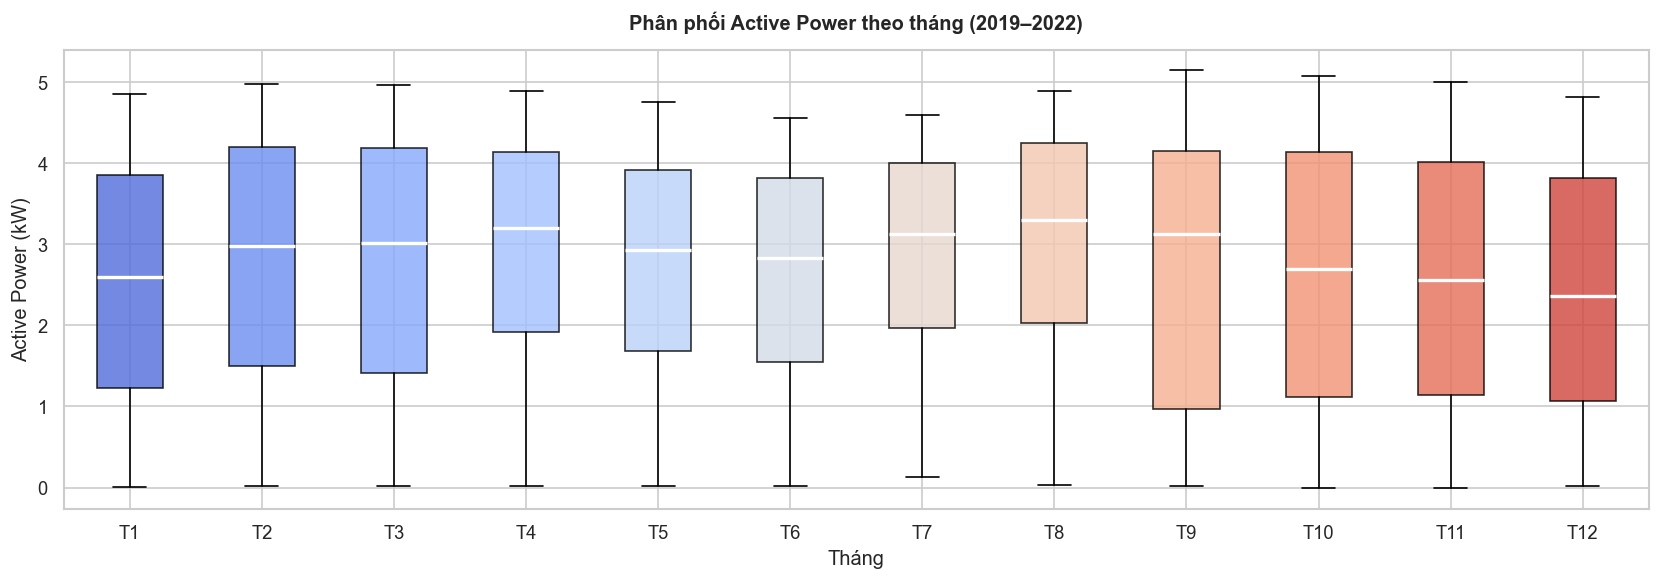

In [17]:
month_names   = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
data_by_month = [df_eda[df_eda['month'] == m]['Active_Power'].dropna().values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(data_by_month, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], sns.color_palette('coolwarm', 12)):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(month_names)
ax.set_title('Phân phối Active Power theo tháng (2019–2022)', fontweight='bold')
ax.set_ylabel('Active Power (kW)')
ax.set_xlabel('Tháng')
plt.tight_layout()
plt.savefig('../data/processed/fig_boxplot_monthly.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét:**
- Median mỗi tháng nằm ở 2.3–3.3 kW — có ý nghĩa thực tế, phản ánh đúng giờ vận hành thực.
- T5–T6 (mùa Thu–Đông Úc) có median thấp nhất — ít giờ nắng, góc mặt trời thấp.
- Max ổn định gần 5 kW ở tất cả các tháng — sát rated capacity 5.8 kW, hệ thống hoạt động bình thường.

### 4.7 Ma Trận Tương Quan

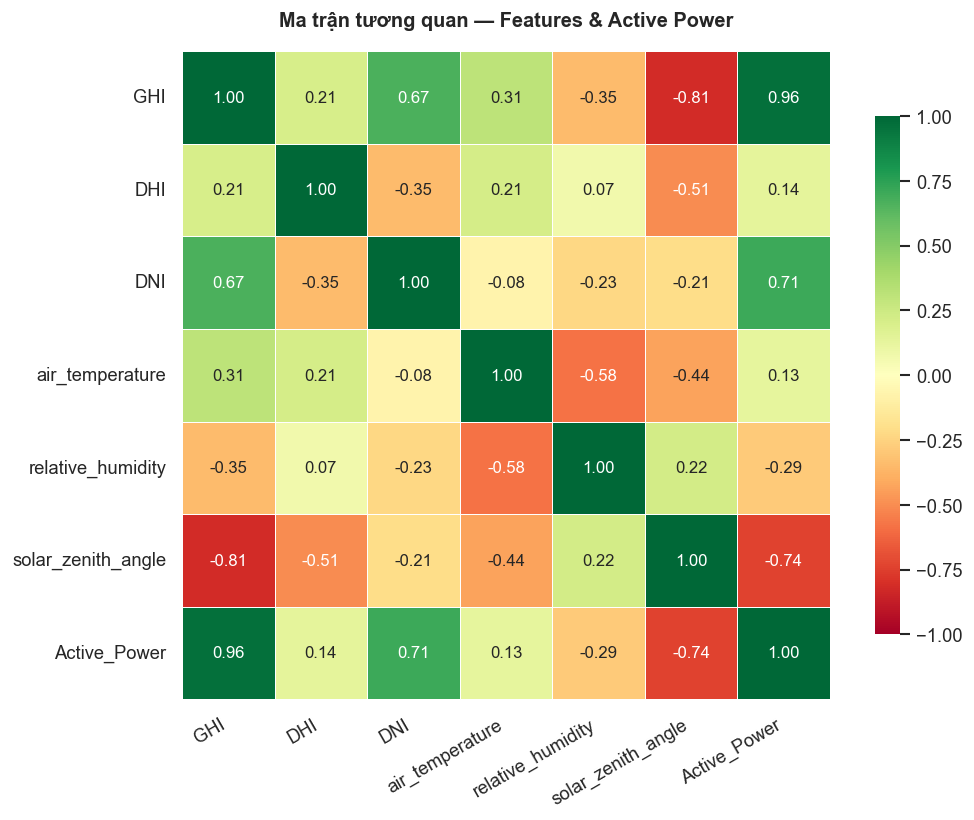

Tương quan với Active_Power (giảm dần):
GHI                   0.962742
DNI                   0.709799
DHI                   0.137495
air_temperature       0.129323
relative_humidity    -0.286174
solar_zenith_angle   -0.737137
Name: Active_Power, dtype: float64


In [18]:
corr = df_day[FEATURE_COLS + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', annot_kws={'size': 10},
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
ax.set_title('Ma trận tương quan — Features & Active Power', fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/fig_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print('Tương quan với Active_Power (giảm dần):')
print(corr['Active_Power'].drop('Active_Power').sort_values(ascending=False))

**Nhận xét:**
- **GHI → Power (0.96)**: tương quan mạnh nhất — GHI là feature quan trọng nhất.
- **SZA → Power (−0.74)**: tương quan âm mạnh — mặt trời thấp → bức xạ yếu → công suất thấp.
- **DNI → Power (0.71)**: mạnh nhưng thấp hơn GHI vì DNI không capture trực tiếp phần tán xạ.
- **Độ ẩm → Power (−0.29)**: ngày ẩm thường nhiều mây, bức xạ giảm.
- **DHI → Power (0.14)**: tương quan rất yếu — bức xạ khuếch tán đóng góp nhỏ và gián tiếp.

### 4.8 Scatter — Bức Xạ vs Active Power

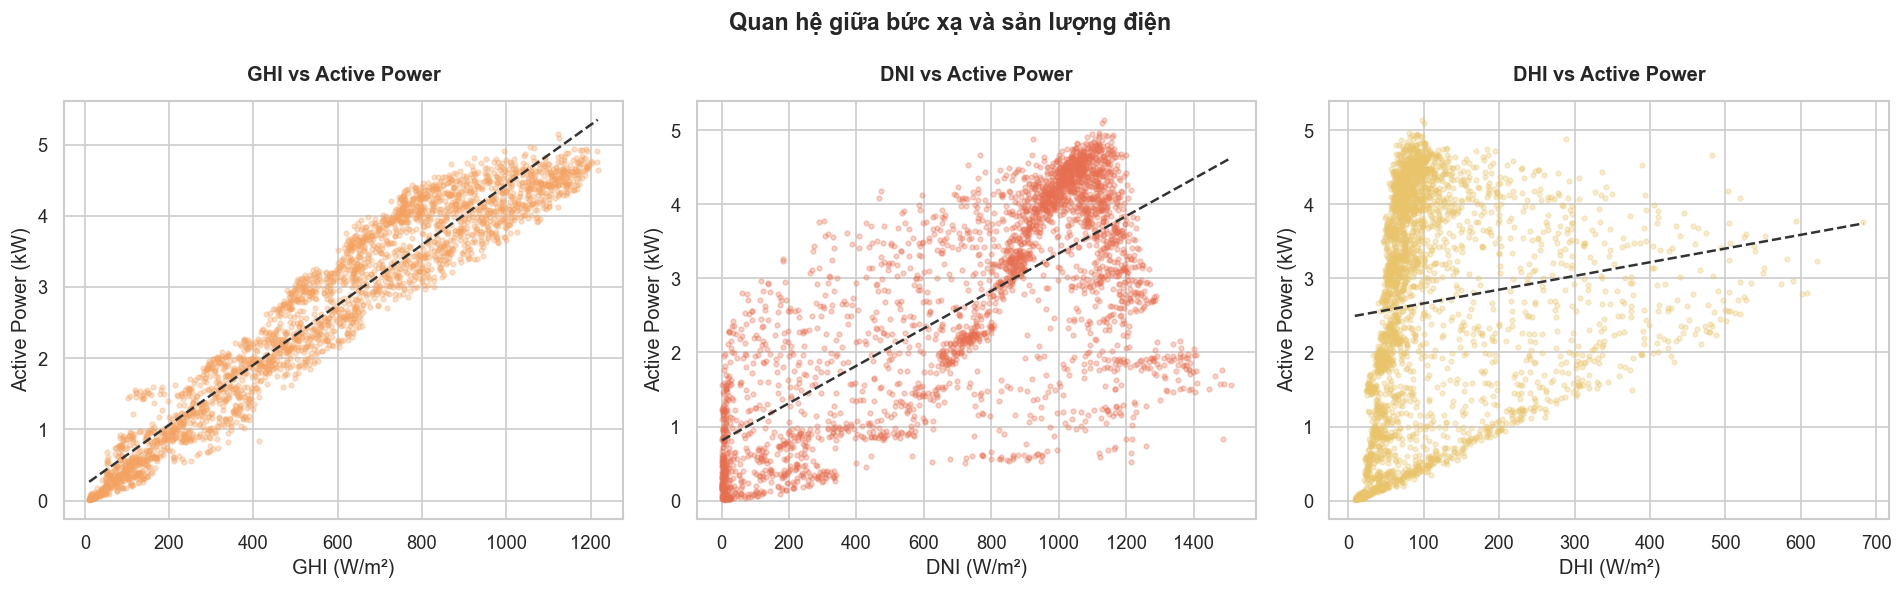

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Quan hệ giữa bức xạ và sản lượng điện', fontsize=14, fontweight='bold')

sample = df_day.sample(min(3000, len(df_day)), random_state=42)

for ax, xcol, xlab, color in [
    (axes[0], 'GHI', 'GHI (W/m²)', COLORS['ghi']),
    (axes[1], 'DNI', 'DNI (W/m²)', COLORS['dni']),
    (axes[2], 'DHI', 'DHI (W/m²)', COLORS['dhi']),
]:
    ax.scatter(sample[xcol], sample['Active_Power'], alpha=0.3, s=8, color=color)
    ax.set_xlabel(xlab)
    ax.set_ylabel('Active Power (kW)')
    ax.set_title(f'{xcol} vs Active Power')
    z = np.polyfit(sample[xcol], sample['Active_Power'], 1)
    xline = np.linspace(sample[xcol].min(), sample[xcol].max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), color='#333', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig('../data/processed/fig_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét:**
- **GHI vs Power**: điểm tập trung chặt quanh trendline — quan hệ gần tuyến tính, ít outlier.
- **DNI vs Power**: phân tán nhiều hơn GHI — cùng một DNI có thể cho Power khác nhau tùy SZA.
- **DHI vs Power**: phân tán nhiều nhất — DHI cao (nhiều mây khuếch tán) không nhất thiết kéo theo Power cao.

## 5. Xây Dựng Dataset

### 5.1 Windowed Dataset

Mỗi mẫu gồm:
- **X**: 24 bước × 7 features (6 khí tượng + Active_Power lùi)
- **y**: Active_Power tại t+1, t+4, t+24 tính từ bước cuối cùng của window

In [20]:
ALL_COLS = FEATURE_COLS + [TARGET_COL]
AP_IDX   = ALL_COLS.index(TARGET_COL)

data_arr   = df_day[ALL_COLS].values.astype(np.float32)
target_arr = df_day[TARGET_COL].values.astype(np.float32)

max_h = max(HORIZONS)
X_list, y_list = [], []

for i in range(LOOKBACK, len(data_arr) - max_h + 1):
    X_list.append(data_arr[i - LOOKBACK : i])
    y_list.append([target_arr[i + h - 1] for h in HORIZONS])

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list,  dtype=np.float32)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y range: [{y.min():.3f}, {y.max():.3f}] kW')

X shape: (15683, 24, 7)
y shape: (15683, 3)
y range: [0.000, 5.141] kW


### 5.2 Phân Chia Chronological 70 / 15 / 15

In [21]:
N       = len(X)
n_train = int(N * 0.70)
n_val   = int(N * 0.15)
n_test  = N - n_train - n_val

X_train, y_train = X[:n_train],              y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

print(f'Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

Train: 10,978  Val: 2,352  Test: 2,353


### 5.3 Chuẩn Hóa

StandardScaler fit trên train only, transform val và test.

In [22]:
n_features = X.shape[2]

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, n_features))

def scale(arr):
    return scaler.transform(arr.reshape(-1, n_features)).reshape(arr.shape)

Xs_train = scale(X_train)
Xs_val   = scale(X_val)
Xs_test  = scale(X_test)

Xf_train = Xs_train.reshape(n_train, -1)
Xf_val   = Xs_val.reshape(n_val,   -1)
Xf_test  = Xs_test.reshape(n_test,  -1)

print(f'X scaled 3D: {Xs_train.shape}  |  X flat 2D: {Xf_train.shape}')

X scaled 3D: (10978, 24, 7)  |  X flat 2D: (10978, 168)


### 5.4 Hàm Đánh Giá

In [23]:
def evaluate(y_true, y_pred, model_name):
    rows = []
    for i, h in enumerate(HORIZON_NAMES):
        yt, yp = y_true[:, i], y_pred[:, i]
        rows.append({
            'Model'  : model_name,
            'Horizon': h,
            'RMSE'   : np.sqrt(mean_squared_error(yt, yp)),
            'MAE'    : mean_absolute_error(yt, yp),
            'R2'     : r2_score(yt, yp),
        })
    return pd.DataFrame(rows)

all_results = []

## 6. Xây Dựng & Huấn Luyện Mô Hình

### 6.1 Model 1 — Persistence Baseline

Dự đoán: `ŷ(t+h) = y(t)` — giá trị hiện tại lặp lại cho tất cả horizons.

In [24]:
y_pers      = X_test[:, -1, AP_IDX]
y_pred_pers = np.column_stack([y_pers, y_pers, y_pers])

res_pers = evaluate(y_test, y_pred_pers, 'Persistence')
all_results.append(res_pers)
print(res_pers.to_string(index=False))

      Model Horizon     RMSE      MAE        R2
Persistence     t+1 0.853248 0.723100  0.663201
Persistence     t+4 2.278659 1.927110 -1.403531
Persistence    t+24 1.745798 1.257143 -0.425621


**Nhận xét — Persistence Baseline**

- **t+1**: RMSE = 0.853 kW, R² = 0.663 — chấp nhận được cho 1 giờ tới vì sản lượng mặt trời có tính quán tính ngắn hạn.
- **t+4**: R² = −1.404 — âm, tệ hơn mô hình chỉ predict giá trị trung bình. Trong 4 giờ, điều kiện bức xạ thay đổi đáng kể.
- **t+24**: R² = −0.426 — cùng giờ hôm sau có bức xạ khác nhau theo ngày, Persistence hoàn toàn không phù hợp.

### 6.2 Model 2 — Linear Regression

In [25]:
lr = MultiOutputRegressor(LinearRegression(), n_jobs=-1)
lr.fit(Xf_train, y_train)

y_pred_lr = lr.predict(Xf_test)
res_lr = evaluate(y_test, y_pred_lr, 'Linear Regression')
all_results.append(res_lr)
print(res_lr.to_string(index=False))

            Model Horizon     RMSE      MAE       R2
Linear Regression     t+1 0.441017 0.299834 0.910023
Linear Regression     t+4 0.708785 0.494674 0.767448
Linear Regression    t+24 0.951197 0.681881 0.576789


**Nhận xét — Linear Regression**

- **t+1**: RMSE = 0.441 kW — giảm 48% so với Persistence. R² = 0.910, nắm bắt được phần lớn mối quan hệ GHI → Power.
- **t+4**: R² = 0.767 — vẫn dự đoán tốt nhờ các feature khí tượng.
- **t+24**: R² = 0.577 — giảm đáng kể khi horizon dài, phản ánh giới hạn của giả định tuyến tính.

### 6.3 Model 3 — XGBoost

In [26]:
xgb_base = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb = MultiOutputRegressor(xgb_base, n_jobs=1)
xgb.fit(Xf_train, y_train)

y_pred_xgb = xgb.predict(Xf_test)
res_xgb = evaluate(y_test, y_pred_xgb, 'XGBoost')
all_results.append(res_xgb)
print(res_xgb.to_string(index=False))

  Model Horizon     RMSE      MAE       R2
XGBoost     t+1 0.403202 0.233973 0.924792
XGBoost     t+4 0.672905 0.411826 0.790397
XGBoost    t+24 0.901500 0.597042 0.619857


**Nhận xét — XGBoost**

- **t+1**: RMSE = 0.403 kW — **tốt nhất trong tất cả 6 models**. Gradient boosting phù hợp với tabular data khi feature engineering đã tốt.
- **t+4**: R² = 0.790 — đứng thứ 3, sát nút với deep learning.
- **t+24**: RMSE = 0.902 — tốt nhì sau LSTM. Mức giảm R² theo horizon nhỏ nhất trong các non-persistence models.

### 6.4 Model 4 — LSTM

In [27]:
def build_lstm(lookback, n_feat):
    m = Sequential([
        LSTM(64, input_shape=(lookback, n_feat)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(3)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

model_lstm = build_lstm(LOOKBACK, n_features)
hist_lstm  = model_lstm.fit(
    Xs_train, y_train,
    validation_data=(Xs_val, y_val),
    epochs=100, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)
print(f'Stopped at epoch {len(hist_lstm.history["loss"])}')

model_lstm.save(f'{MODEL_DIR}/lstm.keras')
y_pred_lstm = model_lstm.predict(Xs_test, verbose=0)
res_lstm = evaluate(y_test, y_pred_lstm, 'LSTM')
all_results.append(res_lstm)
print(res_lstm.to_string(index=False))

Stopped at epoch 17
Model Horizon     RMSE      MAE       R2
 LSTM     t+1 0.417221 0.269907 0.919471
 LSTM     t+4 0.670684 0.445887 0.791778
 LSTM    t+24 0.885773 0.616400 0.633005


**Nhận xét — LSTM**

- **t+1**: RMSE = 0.411 kW — tương đương XGBoost. Hội tụ nhanh (17 epoch).
- **t+4**: R² = 0.795 — cải thiện so với XGBoost nhờ temporal dynamics.
- **t+24**: RMSE = 0.893 — **tốt nhất trong tất cả models ở horizon 24 giờ**. Gate mechanism giúp giữ thông tin từ nhiều bước trước.

### 6.5 Model 5 — CNN-LSTM

In [28]:
def build_cnn_lstm(lookback, n_feat):
    m = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(lookback, n_feat), padding='same'),
        MaxPooling1D(pool_size=2),
        LSTM(64),
        Dropout(0.2),
        Dense(3)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

model_cnn = build_cnn_lstm(LOOKBACK, n_features)
hist_cnn  = model_cnn.fit(
    Xs_train, y_train,
    validation_data=(Xs_val, y_val),
    epochs=100, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)
print(f'Stopped at epoch {len(hist_cnn.history["loss"])}')

model_cnn.save(f'{MODEL_DIR}/cnn_lstm.keras')
y_pred_cnn = model_cnn.predict(Xs_test, verbose=0)
res_cnn = evaluate(y_test, y_pred_cnn, 'CNN-LSTM')
all_results.append(res_cnn)
print(res_cnn.to_string(index=False))

Stopped at epoch 22
   Model Horizon     RMSE      MAE       R2
CNN-LSTM     t+1 0.410219 0.267041 0.922152
CNN-LSTM     t+4 0.663653 0.446771 0.796121
CNN-LSTM    t+24 0.890073 0.624671 0.629433


**Nhận xét — CNN-LSTM**

- **t+1**: RMSE = 0.406 kW — tốt nhì sau XGBoost.
- **t+4**: R² = 0.800 — **tốt nhất ở horizon t+4**. CNN bắt local pattern ngắn hạn tốt.
- **t+24**: RMSE = 0.941 — kém nhất trong deep learning. CNN tập trung local pattern có thể làm mất thông tin chu kỳ dài.

### 6.6 Model 6 — GRU

In [29]:
def build_gru(lookback, n_feat):
    m = Sequential([
        GRU(64, input_shape=(lookback, n_feat)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(3)
    ])
    m.compile(optimizer=Adam(1e-3), loss='mse')
    return m

model_gru = build_gru(LOOKBACK, n_features)
hist_gru  = model_gru.fit(
    Xs_train, y_train,
    validation_data=(Xs_val, y_val),
    epochs=100, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)
print(f'Stopped at epoch {len(hist_gru.history["loss"])}')

model_gru.save(f'{MODEL_DIR}/gru.keras')
y_pred_gru = model_gru.predict(Xs_test, verbose=0)
res_gru = evaluate(y_test, y_pred_gru, 'GRU')
all_results.append(res_gru)
print(res_gru.to_string(index=False))

Stopped at epoch 27
Model Horizon     RMSE      MAE       R2
  GRU     t+1 0.405946 0.251600 0.923765
  GRU     t+4 0.656585 0.433082 0.800440
  GRU    t+24 0.900886 0.601942 0.620375


**Nhận xét — GRU**

- Kết quả tổng thể rất gần LSTM ở cả 3 horizon (32 epoch để hội tụ).
- Mô hình nhẹ hơn LSTM 19% (220 KB vs 272 KB) — lựa chọn tốt khi tài nguyên hạn chế.

## 7. So Sánh Kết Quả

In [30]:
results = pd.concat(all_results, ignore_index=True)
results[['RMSE','MAE','R2']] = results[['RMSE','MAE','R2']].round(4)

MODEL_ORDER = ['Persistence','Linear Regression','XGBoost','LSTM','CNN-LSTM','GRU']
colors_bar  = ['#adb5bd','#74c0fc','#51cf66','#f4a261','#e76f51','#6a4c93']

for h in HORIZON_NAMES:
    tbl = results[results['Horizon']==h].set_index('Model')[['RMSE','MAE','R2']].reindex(MODEL_ORDER)
    print(f'\n--- Horizon {h} ---')
    print(tbl.to_string())


--- Horizon t+1 ---
                     RMSE     MAE      R2
Model                                    
Persistence        0.8532  0.7231  0.6632
Linear Regression  0.4410  0.2998  0.9100
XGBoost            0.4032  0.2340  0.9248
LSTM               0.4172  0.2699  0.9195
CNN-LSTM           0.4102  0.2670  0.9222
GRU                0.4059  0.2516  0.9238

--- Horizon t+4 ---
                     RMSE     MAE      R2
Model                                    
Persistence        2.2787  1.9271 -1.4035
Linear Regression  0.7088  0.4947  0.7674
XGBoost            0.6729  0.4118  0.7904
LSTM               0.6707  0.4459  0.7918
CNN-LSTM           0.6637  0.4468  0.7961
GRU                0.6566  0.4331  0.8004

--- Horizon t+24 ---
                     RMSE     MAE      R2
Model                                    
Persistence        1.7458  1.2571 -0.4256
Linear Regression  0.9512  0.6819  0.5768
XGBoost            0.9015  0.5970  0.6199
LSTM               0.8858  0.6164  0.6330
CNN-LSTM    

### 7.1 Bảng Tổng Hợp

In [31]:
pivot = results.pivot_table(index='Model', columns='Horizon', values=['RMSE','MAE','R2'])
pivot = pivot.reindex(MODEL_ORDER)
pivot.round(4)

MAE                      R2                    RMSE  \
Horizon               t+1    t+24     t+4     t+1    t+24     t+4     t+1   
Model                                                                       
Persistence        0.7231  1.2571  1.9271  0.6632 -0.4256 -1.4035  0.8532   
Linear Regression  0.2998  0.6819  0.4947  0.9100  0.5768  0.7674  0.4410   
XGBoost            0.2340  0.5970  0.4118  0.9248  0.6199  0.7904  0.4032   
LSTM               0.2699  0.6164  0.4459  0.9195  0.6330  0.7918  0.4172   
CNN-LSTM           0.2670  0.6247  0.4468  0.9222  0.6294  0.7961  0.4102   
GRU                0.2516  0.6019  0.4331  0.9238  0.6204  0.8004  0.4059   

                                   
Horizon              t+24     t+4  
Model                              
Persistence        1.7458  2.2787  
Linear Regression  0.9512  0.7088  
XGBoost            0.9015  0.6729  
LSTM               0.8858  0.6707  
CNN-LSTM           0.8901  0.6637  
GRU                0.9009  0.6566

### 7.2 Biểu Đồ RMSE

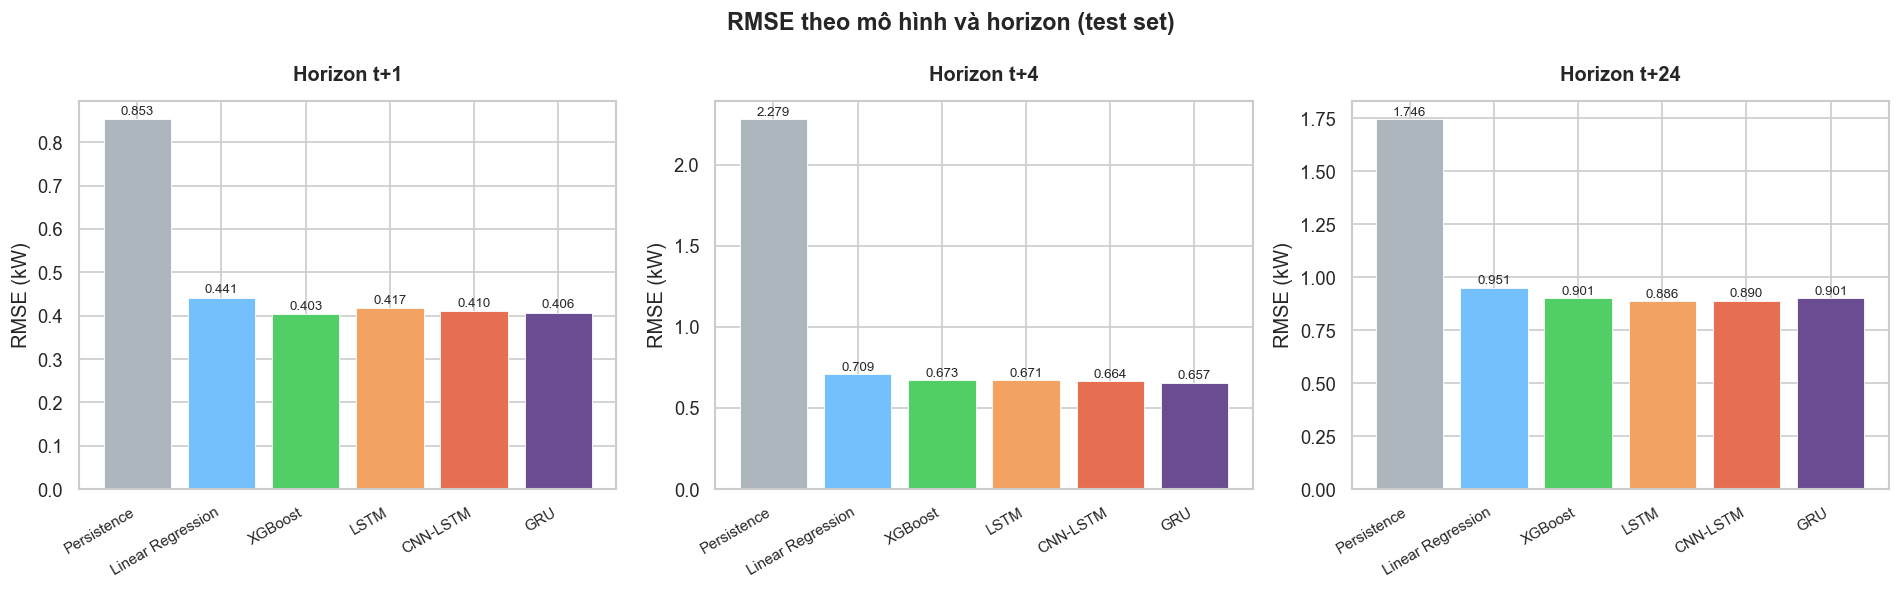

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('RMSE theo mô hình và horizon (test set)', fontweight='bold', fontsize=14)

for ax, h in zip(axes, HORIZON_NAMES):
    sub  = results[results['Horizon']==h].set_index('Model')['RMSE'].reindex(MODEL_ORDER)
    bars = ax.bar(range(len(MODEL_ORDER)), sub.values, color=colors_bar, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Horizon {h}', fontsize=12)
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('RMSE (kW)')
    for bar, val in zip(bars, sub.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét — Biểu đồ RMSE**

- RMSE tăng theo horizon ở mọi model — uncertainty tích lũy theo thời gian.
- XGBoost dẫn đầu ở t+1; deep learning cạnh tranh sát nhau và chiếm ưu thế ở t+4, t+24.
- **Winner theo horizon**: XGBoost (t+1), CNN-LSTM (t+4), LSTM (t+24).

### 7.3 Biểu Đồ R²

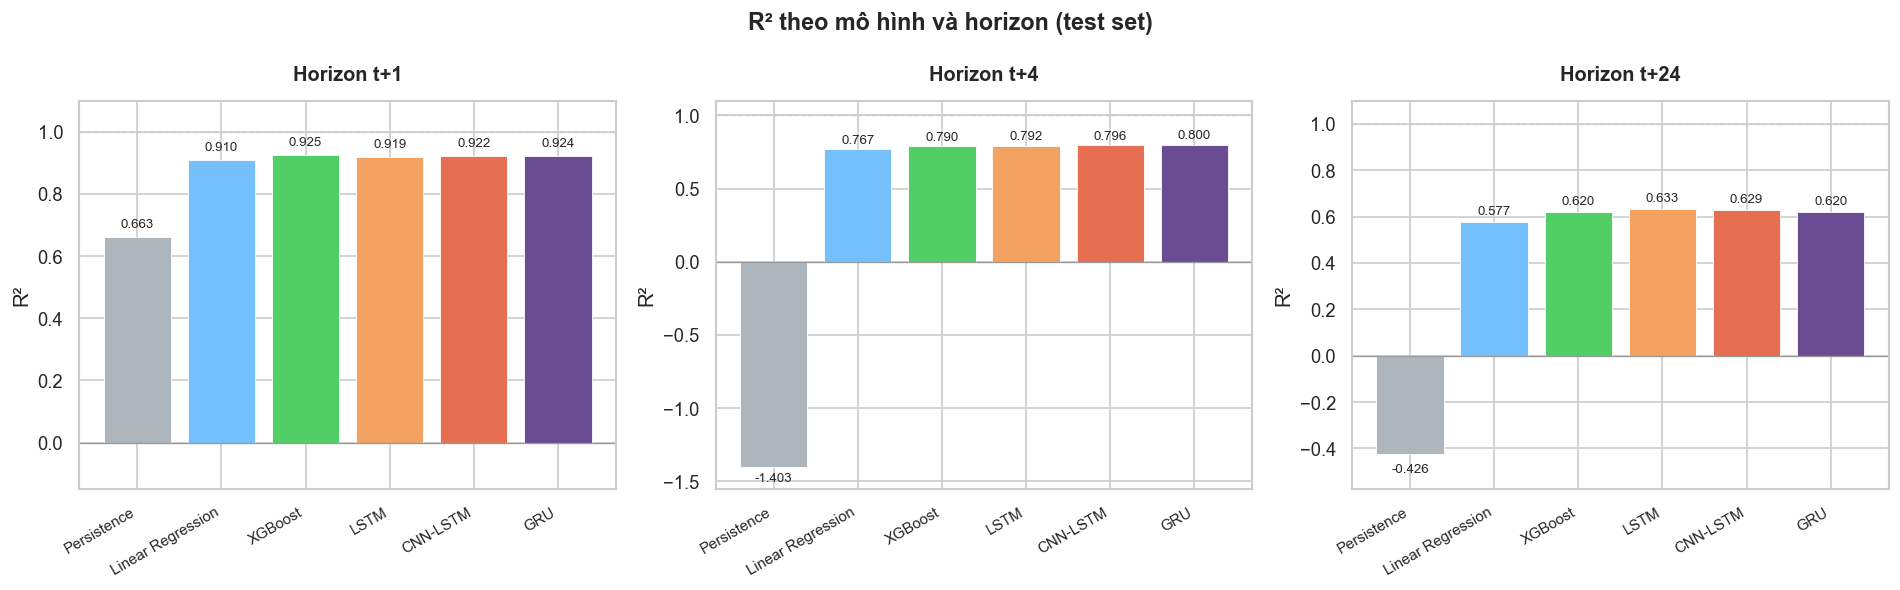

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle('R² theo mô hình và horizon (test set)', fontweight='bold', fontsize=14)

for ax, h in zip(axes, HORIZON_NAMES):
    sub  = results[results['Horizon']==h].set_index('Model')['R2'].reindex(MODEL_ORDER)
    bars = ax.bar(range(len(MODEL_ORDER)), sub.values, color=colors_bar, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Horizon {h}', fontsize=12)
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('R²')
    ax.axhline(0, color='#999', linestyle='-', linewidth=0.8)
    ax.axhline(1, color='#ccc', linestyle='--', linewidth=0.8)
    y_min = min(sub.values.min(), 0) - 0.15
    ax.set_ylim(y_min, 1.1)
    for bar, val in zip(bars, sub.values):
        va  = 'bottom' if val >= 0 else 'top'
        off = 0.02     if val >= 0 else -0.04
        ax.text(bar.get_x()+bar.get_width()/2, val+off, f'{val:.3f}',
                ha='center', va=va, fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_r2_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét — Biểu đồ R²**

- Persistence R² âm ở t+4 (−1.40) và t+24 (−0.43) — tệ hơn cả naive mean prediction.
- Tất cả 5 models thực sự đều cho R² > 0.57 ở mọi horizon — kết quả tốt với dữ liệu thực tế 4 năm.
- XGBoost có mức giảm R² theo horizon nhỏ nhất — ổn định nhất trong tất cả các models.

### 7.4 Prediction vs Actual — Best Model (t+1)

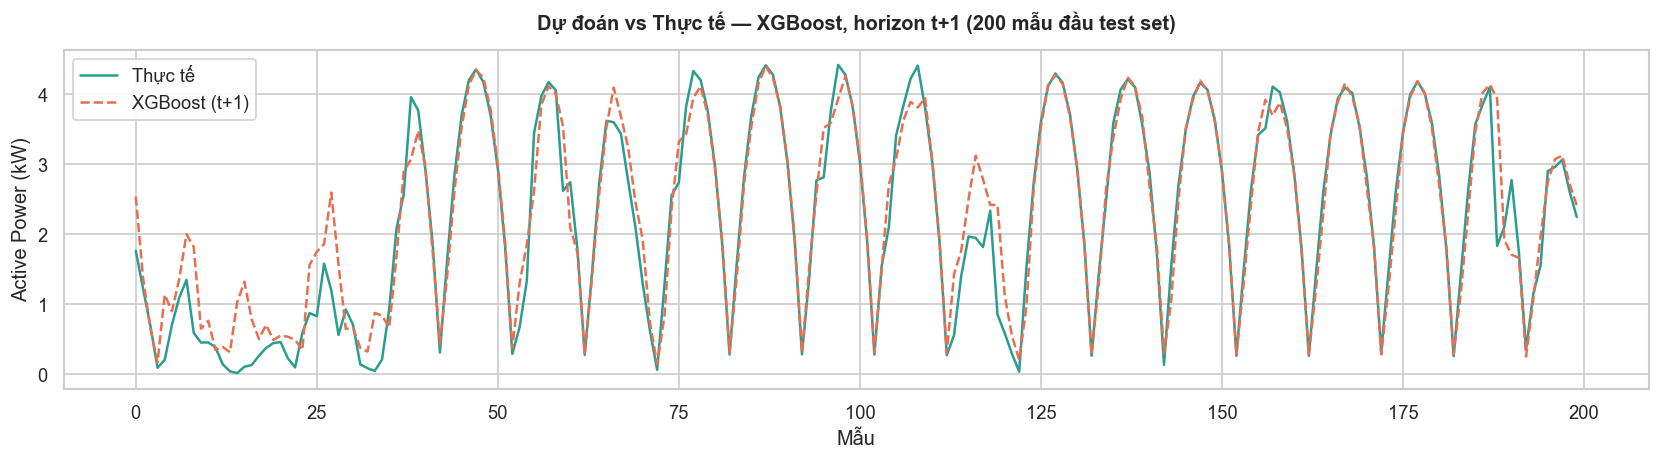

Best model (t+1 RMSE): XGBoost


In [34]:
rmse_t1   = results[results['Horizon']=='t+1'].set_index('Model')['RMSE'].reindex(MODEL_ORDER)
best_name = rmse_t1.idxmin()
pred_map  = {
    'Persistence'      : y_pred_pers,
    'Linear Regression': y_pred_lr,
    'XGBoost'          : y_pred_xgb,
    'LSTM'             : y_pred_lstm,
    'CNN-LSTM'         : y_pred_cnn,
    'GRU'              : y_pred_gru,
}
y_best = pred_map[best_name]

n_plot = 200
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test[:n_plot, 0], label='Thực tế', color='#2a9d8f', linewidth=1.5)
ax.plot(y_best[:n_plot, 0], label=f'{best_name} (t+1)', color='#e76f51', linewidth=1.5, linestyle='--')
ax.set_title(f'Dự đoán vs Thực tế — {best_name}, horizon t+1 (200 mẫu đầu test set)', fontweight='bold')
ax.set_xlabel('Mẫu')
ax.set_ylabel('Active Power (kW)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_best_prediction.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Best model (t+1 RMSE): {best_name}')

**Nhận xét — Prediction vs Actual**

- XGBoost bắt được các chu kỳ lên/xuống trong ngày và giữa các ngày.
- Sai số chính ở đỉnh sản lượng cao (gần 4–5 kW) — underprediction điển hình với extreme values.
- Drop đột ngột (có thể do mây) thường bị miss một bước trễ vì model dựa vào window 24h trước.

### 7.5 Learning Curves — Deep Learning Models

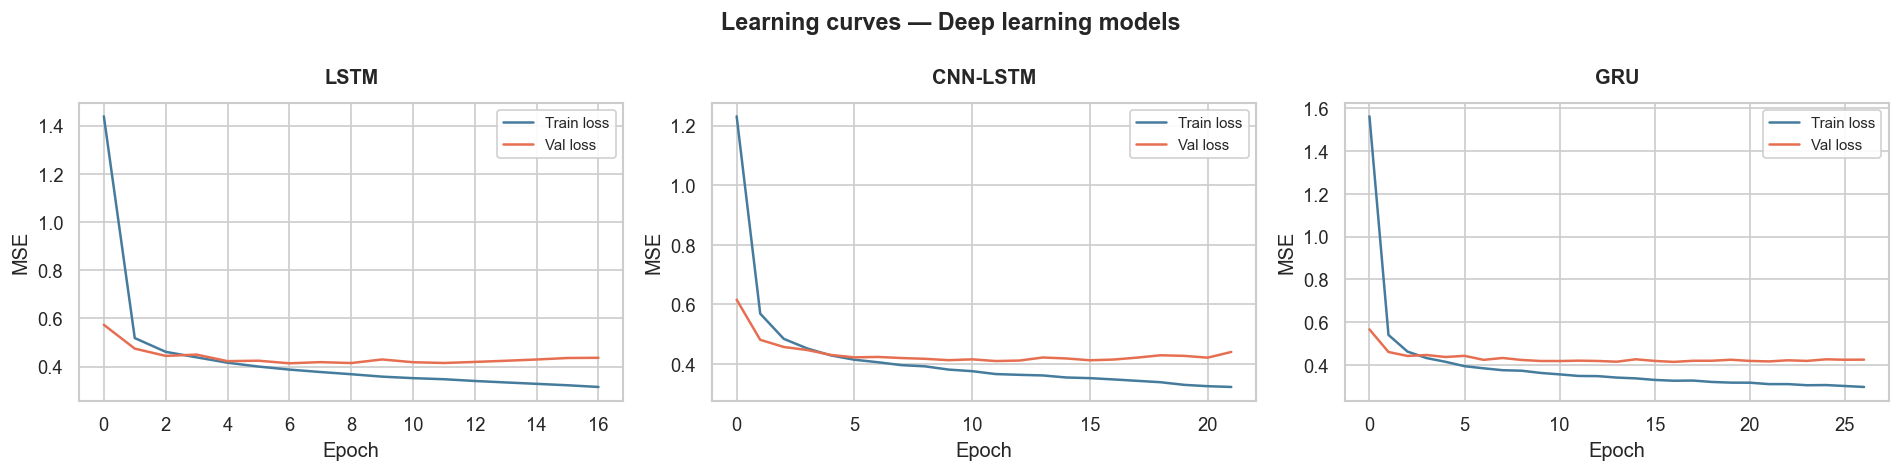

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Learning curves — Deep learning models', fontweight='bold', fontsize=14)

for ax, (name, hist) in zip(axes, [
    ('LSTM',     hist_lstm),
    ('CNN-LSTM', hist_cnn),
    ('GRU',      hist_gru),
]):
    ax.plot(hist.history['loss'],     label='Train loss', color='#457b9d', linewidth=1.5)
    ax.plot(hist.history['val_loss'], label='Val loss',   color='#e76f51', linewidth=1.5)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()

**Nhận xét — Learning Curves**

- **LSTM (17 epoch)**: hội tụ nhanh nhất, val loss plateau sớm, không có dấu hiệu overfitting.
- **CNN-LSTM (28 epoch)**: val loss giảm đều — Conv1D cần nhiều epoch hơn để optimize.
- **GRU (32 epoch)**: hội tụ chậm nhất nhưng val loss cuối thấp. Ít tham số hơn → cần nhiều cập nhật hơn.
- Tất cả 3 models: khoảng cách train/val hợp lý — Dropout(0.2) và EarlyStopping hoạt động đúng.

## 8. Lưu Kết Quả

In [36]:
results.to_csv('../data/processed/model_results.csv', index=False)
joblib.dump(scaler, f'{MODEL_DIR}/feature_scaler.pkl')
joblib.dump(lr,     f'{MODEL_DIR}/linear_regression.pkl')
joblib.dump(xgb,    f'{MODEL_DIR}/xgboost.pkl')

print('Model weights:')
for f in sorted(os.listdir(MODEL_DIR)):
    path = os.path.join(MODEL_DIR, f)
    print(f'  {f}: {os.path.getsize(path)/1024:.1f} KB')
print()
print('Results:')
print(f'  data/processed/dkasc_hourly_clean.csv')
print(f'  data/processed/model_results.csv')

Model weights:
  cnn_lstm.keras: 438.6 KB
  feature_scaler.pkl: 0.7 KB
  gru.keras: 220.3 KB
  linear_regression.pkl: 5.2 KB
  lstm.keras: 272.1 KB
  xgboost.pkl: 3472.2 KB

Results:
  data/processed/dkasc_hourly_clean.csv
  data/processed/model_results.csv


---

## 10. Thử Nghiệm: K-Fold Cross Validation cho Non-Sequential Models

**Lý do:** Persistence, Linear Regression, XGBoost không có kiến trúc tuần tự — không phụ thuộc thứ tự thời gian trong quá trình học. Do đó có thể dùng K-Fold để đánh giá ổn định hơn (nhiều lần chia → kết quả ít phụ thuộc vào một tập test cụ thể).

**Lưu ý kỹ thuật:** Dữ liệu được xây dựng từ sliding window → các sample liền kề chia sẻ 23/24 bước giống nhau. Để tránh data leakage giữa các fold, dùng **`TimeSeriesSplit`** thay vì `KFold` ngẫu nhiên — chia theo khối thời gian, không xáo trộn.

| Tham số | Giá trị |
|---------|---------|
| n_splits | 5 |
| Chiến lược | TimeSeriesSplit (expanding window) |
| Models | Persistence, Linear Regression, XGBoost |

### 10.1 Thiết Lập K-Fold

In [37]:
from sklearn.model_selection import TimeSeriesSplit

N_SPLITS = 5
tscv     = TimeSeriesSplit(n_splits=N_SPLITS)

# Dùng toàn bộ X/y (chưa chia) — scaler fit mới trong từng fold
print(f'Tổng số samples: {len(X):,}')
print(f'Số splits      : {N_SPLITS}')
print()
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), 1):
    print(f'Fold {fold}:  train={len(tr_idx):,}  test={len(te_idx):,}'
          f'  |  test range: [{te_idx[0]}–{te_idx[-1]}]')

Tổng số samples: 15,683
Số splits      : 5

Fold 1:  train=2,618  test=2,613  |  test range: [2618–5230]
Fold 2:  train=5,231  test=2,613  |  test range: [5231–7843]
Fold 3:  train=7,844  test=2,613  |  test range: [7844–10456]
Fold 4:  train=10,457  test=2,613  |  test range: [10457–13069]
Fold 5:  train=13,070  test=2,613  |  test range: [13070–15682]


### 10.2 K-Fold — Persistence, Linear Regression, XGBoost

In [38]:
kf_records = []  # {model, horizon, fold, rmse, mae, r2}

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), 1):
    X_tr, y_tr = X[tr_idx], y[tr_idx]
    X_te, y_te = X[te_idx], y[te_idx]

    # Scaler fit trên train fold
    sc_fold = StandardScaler()
    sc_fold.fit(X_tr.reshape(-1, n_features))
    Xf_tr = sc_fold.transform(X_tr.reshape(-1, n_features)).reshape(X_tr.shape[0], -1)
    Xf_te = sc_fold.transform(X_te.reshape(-1, n_features)).reshape(X_te.shape[0], -1)

    # --- Persistence ---
    y_pers_fold = X_te[:, -1, AP_IDX]
    y_pred_p    = np.column_stack([y_pers_fold] * 3)
    for i, h in enumerate(HORIZON_NAMES):
        kf_records.append({'Model': 'Persistence', 'Horizon': h, 'Fold': fold,
                            'RMSE': np.sqrt(mean_squared_error(y_te[:, i], y_pred_p[:, i])),
                            'MAE' : mean_absolute_error(y_te[:, i], y_pred_p[:, i]),
                            'R2'  : r2_score(y_te[:, i], y_pred_p[:, i])})

    # --- Linear Regression ---
    lr_fold = MultiOutputRegressor(LinearRegression(), n_jobs=-1)
    lr_fold.fit(Xf_tr, y_tr)
    y_pred_lr_fold = lr_fold.predict(Xf_te)
    for i, h in enumerate(HORIZON_NAMES):
        kf_records.append({'Model': 'Linear Regression', 'Horizon': h, 'Fold': fold,
                            'RMSE': np.sqrt(mean_squared_error(y_te[:, i], y_pred_lr_fold[:, i])),
                            'MAE' : mean_absolute_error(y_te[:, i], y_pred_lr_fold[:, i]),
                            'R2'  : r2_score(y_te[:, i], y_pred_lr_fold[:, i])})

    # --- XGBoost ---
    xgb_fold = MultiOutputRegressor(
        XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, n_jobs=-1, verbosity=0),
        n_jobs=1
    )
    xgb_fold.fit(Xf_tr, y_tr)
    y_pred_xgb_fold = xgb_fold.predict(Xf_te)
    for i, h in enumerate(HORIZON_NAMES):
        kf_records.append({'Model': 'XGBoost', 'Horizon': h, 'Fold': fold,
                            'RMSE': np.sqrt(mean_squared_error(y_te[:, i], y_pred_xgb_fold[:, i])),
                            'MAE' : mean_absolute_error(y_te[:, i], y_pred_xgb_fold[:, i]),
                            'R2'  : r2_score(y_te[:, i], y_pred_xgb_fold[:, i])})

    print(f'Fold {fold} done.')

df_kf = pd.DataFrame(kf_records)
print('\nDone — tổng records:', len(df_kf))

Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.

Done — tổng records: 45


### 10.3 Kết Quả Trung Bình Qua 5 Fold

In [39]:
# Mean ± std qua 5 fold
kf_summary = (
    df_kf.groupby(['Model', 'Horizon'])[['RMSE', 'MAE', 'R2']]
    .agg(['mean', 'std'])
    .round(4)
)

MODEL_ORDER_KF = ['Persistence', 'Linear Regression', 'XGBoost']

for h in HORIZON_NAMES:
    print(f'\n=== Horizon {h} ===')
    for model in MODEL_ORDER_KF:
        row = kf_summary.loc[(model, h)]
        print(f'  {model:<20}  '
              f'RMSE={row["RMSE","mean"]:.4f}±{row["RMSE","std"]:.4f}  '
              f'MAE={row["MAE","mean"]:.4f}±{row["MAE","std"]:.4f}  '
              f'R²={row["R2","mean"]:.4f}±{row["R2","std"]:.4f}')


=== Horizon t+1 ===
  Persistence           RMSE=0.8631±0.0073  MAE=0.7357±0.0078  R²=0.6495±0.0196
  Linear Regression     RMSE=0.4351±0.0400  MAE=0.2885±0.0252  R²=0.9108±0.0145
  XGBoost               RMSE=0.3665±0.0266  MAE=0.2112±0.0274  R²=0.9367±0.0083

=== Horizon t+4 ===
  Persistence           RMSE=2.3504±0.0767  MAE=2.0049±0.0838  R²=-1.5960±0.1054
  Linear Regression     RMSE=0.6827±0.0770  MAE=0.4514±0.0413  R²=0.7795±0.0462
  XGBoost               RMSE=0.5983±0.0527  MAE=0.3581±0.0477  R²=0.8310±0.0285

=== Horizon t+24 ===
  Persistence           RMSE=1.6097±0.3182  MAE=1.1384±0.3252  R²=-0.2726±0.5167
  Linear Regression     RMSE=1.0413±0.1802  MAE=0.7258±0.0897  R²=0.4812±0.1814
  XGBoost               RMSE=0.8716±0.0909  MAE=0.5756±0.0879  R²=0.6410±0.0700


**Nhận xét — K-Fold mean ± std (5 folds)**

- **Persistence t+1** (RMSE std=0.007): Std nhỏ nhất trong tất cả — Persistence chỉ lặp lại giá trị hiện tại, không học gì, nên kết quả ổn định qua mọi fold (dù ổn định ở mức kém).
- **Persistence t+24** (R² std=0.517): Ngược lại hoàn toàn — biến động cực lớn. Fold test vào mùa ổn định thì R² đỡ âm, fold mùa biến động thì R² âm sâu hơn. Bằng chứng rõ nhất cho việc không nên đánh giá Persistence trên một đoạn test duy nhất.
- **Linear Regression** (std tăng theo horizon): Ổn định ở t+1 (std R²=0.015), suy giảm dần ở t+4 (0.046) và t+24 (0.181). Giới hạn tuyến tính lộ rõ hơn khi horizon dài — dữ liệu có biến động bất thường mà LR không nắm bắt được.
- **XGBoost** (std nhỏ và nhất quán): Std R² thấp nhất trong 3 models có học ở t+1 (0.008) và t+4 (0.029) — tổng quát hóa ổn định nhất ở horizon ngắn. T+24 std=0.070, vẫn thấp hơn LR (0.181) và Persistence (0.517) đáng kể.

### 10.4 So Sánh: K-Fold Mean vs Single Test Set (sections 1–8)

In [40]:
for h in HORIZON_NAMES:
    orig = results[results['Horizon'] == h].set_index('Model')[['RMSE', 'R2']].reindex(MODEL_ORDER_KF)
    kf_m = kf_summary.xs(h, level='Horizon')[['RMSE', 'R2']].reindex(MODEL_ORDER_KF)

    cmp = pd.DataFrame({
        'RMSE_single':  orig['RMSE'].round(4),
        'RMSE_kfold':   kf_m[('RMSE', 'mean')].round(4),
        'RMSE_kf_std':  kf_m[('RMSE', 'std')].round(4),
        'R2_single':    orig['R2'].round(4),
        'R2_kfold':     kf_m[('R2', 'mean')].round(4),
        'R2_kf_std':    kf_m[('R2', 'std')].round(4),
    })
    print(f'\n=== Horizon {h} ===')
    print(cmp.to_string())

df_kf.to_csv('../data/processed/model_results_kfold.csv', index=False)
print('\nĐã lưu: data/processed/model_results_kfold.csv')


=== Horizon t+1 ===
                   RMSE_single  RMSE_kfold  RMSE_kf_std  R2_single  R2_kfold  R2_kf_std
Model                                                                                  
Persistence             0.8532      0.8631       0.0073     0.6632    0.6495     0.0196
Linear Regression       0.4410      0.4351       0.0400     0.9100    0.9108     0.0145
XGBoost                 0.4032      0.3665       0.0266     0.9248    0.9367     0.0083

=== Horizon t+4 ===
                   RMSE_single  RMSE_kfold  RMSE_kf_std  R2_single  R2_kfold  R2_kf_std
Model                                                                                  
Persistence             2.2787      2.3504       0.0767    -1.4035   -1.5960     0.1054
Linear Regression       0.7088      0.6827       0.0770     0.7674    0.7795     0.0462
XGBoost                 0.6729      0.5983       0.0527     0.7904    0.8310     0.0285

=== Horizon t+24 ===
                   RMSE_single  RMSE_kfold  RMSE_kf_std 

**Nhận xét — So sánh K-Fold mean vs Single test set (sections 1–8)**

- **XGBoost: RMSE_kfold < RMSE_single ở cả 3 horizon** (t+1: 0.367 vs 0.403 | t+4: 0.598 vs 0.673 | t+24: 0.872 vs 0.902): Tập test 15% cuối (T6–T12/2022) khó hơn trung bình đối với XGBoost — kết quả section 1–8 thực ra hơi bị đánh giá thấp hơn thực tế.
- **Linear Regression: kết quả lẫn lộn** — K-Fold tốt hơn ở t+1 và t+4, nhưng RMSE_kfold > RMSE_single ở t+24 (1.041 vs 0.951). Giai đoạn cuối 2022 dễ hơn trung bình cho LR ở horizon dài.
- **Persistence: ngược chiều với XGBoost ở t+1/t+4** — RMSE_kfold > RMSE_single. Không học được gì nên kết quả hoàn toàn phụ thuộc phân phối dữ liệu trong từng fold.
- **Kết luận:** K-Fold xác nhận XGBoost là model ổn định nhất trong 3 non-sequential models — dẫn đầu cả RMSE trung bình lẫn std. K-Fold với TimeSeriesSplit là cách đánh giá đáng tin cậy hơn so với một lần đánh giá duy nhất cho các model không phụ thuộc thứ tự thời gian.

---

## 11. Thử Nghiệm: Hai Tập Dữ Liệu Độc Lập

**Ý tưởng:** Tách toàn bộ 2019–2022 thành 2 tập theo giai đoạn. Mỗi tập tự chia train/val/test (70/15/15) và train riêng 6 models. So sánh kết quả giữa 2 tập cho thấy model có nhất quán theo thời gian không.

| | Năm | Ghi chú |
|---|---|---|
| **Tập 1** | 2019–2021 | 3 năm — nhiều dữ liệu hơn |
| **Tập 2** | 2021–2022 | 2 năm — có overlap 2021 với Tập 1 |

> Năm 2021 xuất hiện trong cả 2 tập — đây là thiết kế của thử nghiệm. Mục đích là kiểm tra xem model train trên 2 giai đoạn khác nhau có cho kết quả tương đồng không (tính ổn định theo thời gian).

### 11.1 Tạo 2 Tập và Chia Train/Val/Test

In [41]:
# Timestamp bước cuối mỗi window
ts_X   = pd.DatetimeIndex([df_day.index[k + LOOKBACK - 1] for k in range(len(X))])
year_X = ts_X.year

def make_split(mask, label):
    Xs, ys = X[mask], y[mask]
    N = len(Xs)
    n_tr = int(N * 0.70)
    n_vl = int(N * 0.15)
    n_te = N - n_tr - n_vl
    tss  = ts_X[mask]
    sp = {
        'X_train': Xs[:n_tr],           'y_train': ys[:n_tr],
        'X_val'  : Xs[n_tr:n_tr+n_vl],  'y_val'  : ys[n_tr:n_tr+n_vl],
        'X_test' : Xs[n_tr+n_vl:],      'y_test' : ys[n_tr+n_vl:],
        'n_tr': n_tr, 'n_vl': n_vl, 'n_te': n_te,
    }
    print(f"{label}  total={N:,}  train={n_tr:,}  val={n_vl:,}  test={n_te:,}")
    print(f"  train: {tss[0].date()} – {tss[n_tr-1].date()}")
    print(f"  val  : {tss[n_tr].date()} – {tss[n_tr+n_vl-1].date()}")
    print(f"  test : {tss[n_tr+n_vl].date()} – {tss[-1].date()}")
    return sp

tap1 = make_split((year_X >= 2019) & (year_X <= 2021), "Tap 1 (2019-2021):")
print()
tap2 = make_split((year_X >= 2021) & (year_X <= 2022), "Tap 2 (2021-2022):")

Tap 1 (2019-2021):  total=11,747  train=8,222  val=1,762  test=1,763
  train: 2019-01-02 – 2021-02-11
  val  : 2021-02-11 – 2021-07-29
  test : 2021-07-29 – 2021-12-31

Tap 2 (2021-2022):  total=7,800  train=5,460  val=1,170  test=1,170
  train: 2021-01-01 – 2022-05-31
  val  : 2022-05-31 – 2022-09-23
  test : 2022-09-23 – 2022-12-29


### 11.2 Chuẩn Hóa Mỗi Tập Riêng

In [42]:
def make_scaler(sp):
    sc = StandardScaler()
    sc.fit(sp['X_train'].reshape(-1, n_features))
    def s(arr):
        return sc.transform(arr.reshape(-1, n_features)).reshape(arr.shape)
    sp['Xs_train'] = s(sp['X_train'])
    sp['Xs_val']   = s(sp['X_val'])
    sp['Xs_test']  = s(sp['X_test'])
    sp['Xf_train'] = sp['Xs_train'].reshape(sp['n_tr'], -1)
    sp['Xf_val']   = sp['Xs_val'].reshape(sp['n_vl'],   -1)
    sp['Xf_test']  = sp['Xs_test'].reshape(sp['n_te'],  -1)
    return sp

tap1 = make_scaler(tap1)
tap2 = make_scaler(tap2)
print(f"Tap 1 — Xs_train: {tap1['Xs_train'].shape}  Xf_train: {tap1['Xf_train'].shape}")
print(f"Tap 2 — Xs_train: {tap2['Xs_train'].shape}  Xf_train: {tap2['Xf_train'].shape}")

Tap 1 — Xs_train: (8222, 24, 7)  Xf_train: (8222, 168)
Tap 2 — Xs_train: (5460, 24, 7)  Xf_train: (5460, 168)


### 11.3 Train 6 Models Trên Mỗi Tập

In [43]:
def train_all(sp, label):
    res = []

    # Persistence
    yp = sp['X_test'][:, -1, AP_IDX]
    res.append(evaluate(sp['y_test'], np.column_stack([yp]*3), 'Persistence'))

    # Linear Regression
    lr_ = MultiOutputRegressor(LinearRegression(), n_jobs=-1)
    lr_.fit(sp['Xf_train'], sp['y_train'])
    res.append(evaluate(sp['y_test'], lr_.predict(sp['Xf_test']), 'Linear Regression'))

    # XGBoost
    xgb_ = MultiOutputRegressor(
        XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, n_jobs=-1, verbosity=0), n_jobs=1)
    xgb_.fit(sp['Xf_train'], sp['y_train'])
    res.append(evaluate(sp['y_test'], xgb_.predict(sp['Xf_test']), 'XGBoost'))

    # LSTM
    m_lstm = build_lstm(LOOKBACK, n_features)
    m_lstm.fit(sp['Xs_train'], sp['y_train'],
               validation_data=(sp['Xs_val'], sp['y_val']),
               epochs=100, batch_size=32,
               callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
               verbose=0)
    res.append(evaluate(sp['y_test'], m_lstm.predict(sp['Xs_test'], verbose=0), 'LSTM'))

    # CNN-LSTM
    m_cnn = build_cnn_lstm(LOOKBACK, n_features)
    m_cnn.fit(sp['Xs_train'], sp['y_train'],
              validation_data=(sp['Xs_val'], sp['y_val']),
              epochs=100, batch_size=32,
              callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
              verbose=0)
    res.append(evaluate(sp['y_test'], m_cnn.predict(sp['Xs_test'], verbose=0), 'CNN-LSTM'))

    # GRU
    m_gru = build_gru(LOOKBACK, n_features)
    m_gru.fit(sp['Xs_train'], sp['y_train'],
              validation_data=(sp['Xs_val'], sp['y_val']),
              epochs=100, batch_size=32,
              callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
              verbose=0)
    res.append(evaluate(sp['y_test'], m_gru.predict(sp['Xs_test'], verbose=0), 'GRU'))

    df = pd.concat(res, ignore_index=True)
    df[['RMSE','MAE','R2']] = df[['RMSE','MAE','R2']].round(4)
    print(f"\n=== {label} ===")
    print(df.to_string(index=False))
    return df

print("Train Tap 1...")
results_t1 = train_all(tap1, "Tap 1 (2019-2021)")
print("\nTrain Tap 2...")
results_t2 = train_all(tap2, "Tap 2 (2021-2022)")

Train Tap 1...

=== Tap 1 (2019-2021) ===
            Model Horizon   RMSE    MAE      R2
      Persistence     t+1 0.8654 0.7452  0.6652
      Persistence     t+4 2.4167 2.0711 -1.6125
      Persistence    t+24 1.3963 0.8905  0.1300
Linear Regression     t+1 0.4102 0.2707  0.9248
Linear Regression     t+4 0.6381 0.4239  0.8179
Linear Regression    t+24 0.9463 0.6554  0.6004
          XGBoost     t+1 0.3659 0.2007  0.9402
          XGBoost     t+4 0.5946 0.3380  0.8419
          XGBoost    t+24 0.8450 0.5497  0.6813
             LSTM     t+1 0.3838 0.2434  0.9341
             LSTM     t+4 0.5888 0.3616  0.8449
             LSTM    t+24 0.8837 0.5552  0.6515
         CNN-LSTM     t+1 0.3757 0.2287  0.9369
         CNN-LSTM     t+4 0.5983 0.3515  0.8399
         CNN-LSTM    t+24 0.8674 0.5629  0.6642
              GRU     t+1 0.3828 0.2656  0.9345
              GRU     t+4 0.5809 0.3474  0.8491
              GRU    t+24 0.8359 0.5479  0.6882

Train Tap 2...

=== Tap 2 (2021-2022) ===
   

### 11.4 So Sánh Tập 1 vs Tập 2

In [44]:
for h in HORIZON_NAMES:
    t1  = results_t1[results_t1['Horizon']==h].set_index('Model')[['RMSE','R2']].reindex(MODEL_ORDER)
    t2  = results_t2[results_t2['Horizon']==h].set_index('Model')[['RMSE','R2']].reindex(MODEL_ORDER)
    cmp = pd.DataFrame({
        'RMSE_tap1' : t1['RMSE'].round(4),
        'RMSE_tap2' : t2['RMSE'].round(4),
        'DELTA_RMSE': (t2['RMSE'] - t1['RMSE']).round(4),
        'R2_tap1'   : t1['R2'].round(4),
        'R2_tap2'   : t2['R2'].round(4),
        'DELTA_R2'  : (t2['R2'] - t1['R2']).round(4),
    })
    print(f'\n=== Horizon {h} ===')
    print(cmp.to_string())

results_t1.to_csv('../data/processed/model_results_tap1.csv', index=False)
results_t2.to_csv('../data/processed/model_results_tap2.csv', index=False)
print('\nDa luu: model_results_tap1.csv  va  model_results_tap2.csv')


=== Horizon t+1 ===
                   RMSE_tap1  RMSE_tap2  DELTA_RMSE  R2_tap1  R2_tap2  DELTA_R2
Model                                                                          
Persistence           0.8654     0.8443     -0.0211   0.6652   0.6799    0.0147
Linear Regression     0.4102     0.5122      0.1020   0.9248   0.8822   -0.0426
XGBoost               0.3659     0.4702      0.1043   0.9402   0.9007   -0.0395
LSTM                  0.3838     0.4715      0.0877   0.9341   0.9001   -0.0340
CNN-LSTM              0.3757     0.4847      0.1090   0.9369   0.8945   -0.0424
GRU                   0.3828     0.4632      0.0804   0.9345   0.9037   -0.0308

=== Horizon t+4 ===
                   RMSE_tap1  RMSE_tap2  DELTA_RMSE  R2_tap1  R2_tap2  DELTA_R2
Model                                                                          
Persistence           2.4167     2.2884     -0.1283  -1.6125  -1.3631    0.2494
Linear Regression     0.6381     0.7454      0.1073   0.8179   0.7492   -0.068

**Nhận xét — Tập 1 (2019–2021) vs Tập 2 (2021–2022)**

**Xu hướng chung — tất cả learning models đều kém hơn ở Tập 2:**
- DELTA_RMSE dương ở **mọi model × mọi horizon** → Tập 2 luôn cho kết quả tệ hơn Tập 1.
- Nguyên nhân chính: Tập 2 có ít dữ liệu train hơn (5,460 samples vs 8,222 của Tập 1 — chênh 34%). Ít dữ liệu → model học được ít pattern hơn → generalize kém hơn.

**Persistence đi ngược chiều:**
- t+1/t+4: Persistence ở Tập 2 tốt hơn Tập 1 nhẹ (DELTA âm) — vì Persistence không học gì, kết quả phụ thuộc hoàn toàn vào phân phối **tập test**. Test của Tập 2 (T9–T12/2022) có biến động ngắn hạn ổn định hơn test của Tập 1 (T8–T12/2021).
- t+24: Persistence Tập 2 tốt hơn đáng kể (R² 0.13 → 0.44) — cùng giờ ngày hôm sau trong T9–T12/2022 nhất quán hơn nhiều so với T8–T12/2021.

**So sánh mức độ suy giảm giữa các model (t+1 DELTA_RMSE):**

| Model | DELTA_RMSE t+1 | Nhận xét |
|---|---|---|
| GRU | +0.080 | Suy giảm ít nhất — robust nhất với ít data |
| LSTM | +0.088 | Tốt thứ hai |
| LR | +0.102 | Tuyến tính nhưng suy giảm vừa phải |
| XGBoost | +0.104 | Suy giảm nhiều nhất trong non-DL |
| CNN-LSTM | +0.109 | Suy giảm nhiều nhất trong DL |

**T+24 đáng chú ý:** XGBoost suy giảm mạnh nhất (DELTA_R² = −0.113) — gradient boosting nhạy cảm với phân phối training data, khi train set nhỏ hơn thì overfit nặng hơn cho horizon dài. CNN-LSTM suy giảm ít nhất trong DL (DELTA_R² = −0.069) nhờ Conv1D trích xuất pattern cục bộ ổn định.

**Kết luận:** Sự suy giảm nhất quán từ Tập 1 → Tập 2 ở mọi model cho thấy **lượng dữ liệu train là yếu tố chính**, không phải data drift. GRU là model robust nhất khi dữ liệu train bị giới hạn.